In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv("../data/superstore.csv", encoding="latin-1")
df['Order Date'] = pd.to_datetime(df['Order Date'])

print("Ready.")

Ready.


In [2]:
# Prepare monthly sales data
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))
monthly_sales = monthly_sales.sort_values('Date').reset_index(drop=True)

# Create a time index — month number from the start (1, 2, 3 ... 48)
monthly_sales['Time_Index'] = range(1, len(monthly_sales) + 1)

print(monthly_sales.head(10))

   Year  Month       Sales       Date  Time_Index
0  2014      1  14236.8950 2014-01-01           1
1  2014      2   4519.8920 2014-02-01           2
2  2014      3  55691.0090 2014-03-01           3
3  2014      4  28295.3450 2014-04-01           4
4  2014      5  23648.2870 2014-05-01           5
5  2014      6  34595.1276 2014-06-01           6
6  2014      7  33946.3930 2014-07-01           7
7  2014      8  27909.4685 2014-08-01           8
8  2014      9  81777.3508 2014-09-01           9
9  2014     10  31453.3930 2014-10-01          10


In [3]:
# Define features and target
X = monthly_sales[['Time_Index']]
y = monthly_sales['Sales']

# Split — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 38
Testing samples: 10


In [4]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")
print("Trend (slope):", round(model.coef_[0], 2))
print("Base Sales (intercept):", round(model.intercept_, 2))

Model trained.
Trend (slope): 699.55
Base Sales (intercept): 29207.74


In [5]:
# Evaluate the model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 3))

Mean Absolute Error (MAE): 18041.64
Root Mean Squared Error (RMSE): 23416.38
R² Score: 0.034


## Model Evaluation — Linear Regression (Baseline)

| Metric | Value |
|---|---|
| MAE | $18,041 |
| RMSE | $23,416 |
| R² Score | 0.034 |

**Finding:** The baseline model is weak — R² of 0.034 means it explains 
only 3.4% of sales variation. The high volatility and seasonality in the 
data cannot be captured by a simple linear trend.

**Next Step:** Engineer seasonal features to improve model performance.

In [6]:
# Add seasonal features
monthly_sales['Month_Sin'] = np.sin(2 * np.pi * monthly_sales['Month'] / 12)
monthly_sales['Month_Cos'] = np.cos(2 * np.pi * monthly_sales['Month'] / 12)
monthly_sales['Q4'] = monthly_sales['Month'].isin([10, 11, 12]).astype(int)
monthly_sales['Q1'] = monthly_sales['Month'].isin([1, 2, 3]).astype(int)

print(monthly_sales[['Month', 'Month_Sin', 'Month_Cos', 'Q4', 'Q1']].head(12))

    Month     Month_Sin     Month_Cos  Q4  Q1
0       1  5.000000e-01  8.660254e-01   0   1
1       2  8.660254e-01  5.000000e-01   0   1
2       3  1.000000e+00  6.123234e-17   0   1
3       4  8.660254e-01 -5.000000e-01   0   0
4       5  5.000000e-01 -8.660254e-01   0   0
5       6  1.224647e-16 -1.000000e+00   0   0
6       7 -5.000000e-01 -8.660254e-01   0   0
7       8 -8.660254e-01 -5.000000e-01   0   0
8       9 -1.000000e+00 -1.836970e-16   0   0
9      10 -8.660254e-01  5.000000e-01   1   0
10     11 -5.000000e-01  8.660254e-01   1   0
11     12 -2.449294e-16  1.000000e+00   1   0


In [7]:
# Retrain with seasonal features
X2 = monthly_sales[['Time_Index', 'Month_Sin', 'Month_Cos', 'Q4', 'Q1']]
y2 = monthly_sales['Sales']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, shuffle=False)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2 = r2_score(y2_test, y2_pred)

print("Improved Model Results:")
print("MAE:", round(mae2, 2))
print("RMSE:", round(rmse2, 2))
print("R² Score:", round(r2_2, 3))

Improved Model Results:
MAE: 14512.49
RMSE: 19291.44
R² Score: 0.345


## Model Comparison

| Metric | Baseline | Improved |
|---|---|---|
| MAE | $18,041 | $14,512 |
| RMSE | $23,416 | $19,291 |
| R² Score | 0.034 | 0.345 |

**Improvement:** Adding seasonal features (sin/cos encoding, Q4 and Q1 flags)
improved R² by 31 percentage points — from 3.4% to 34.5%.

**Limitation:** High month-to-month volatility driven by promotions and 
bulk orders limits linear model performance. A more advanced model like
Random Forest or XGBoost would capture this non-linear behavior better.


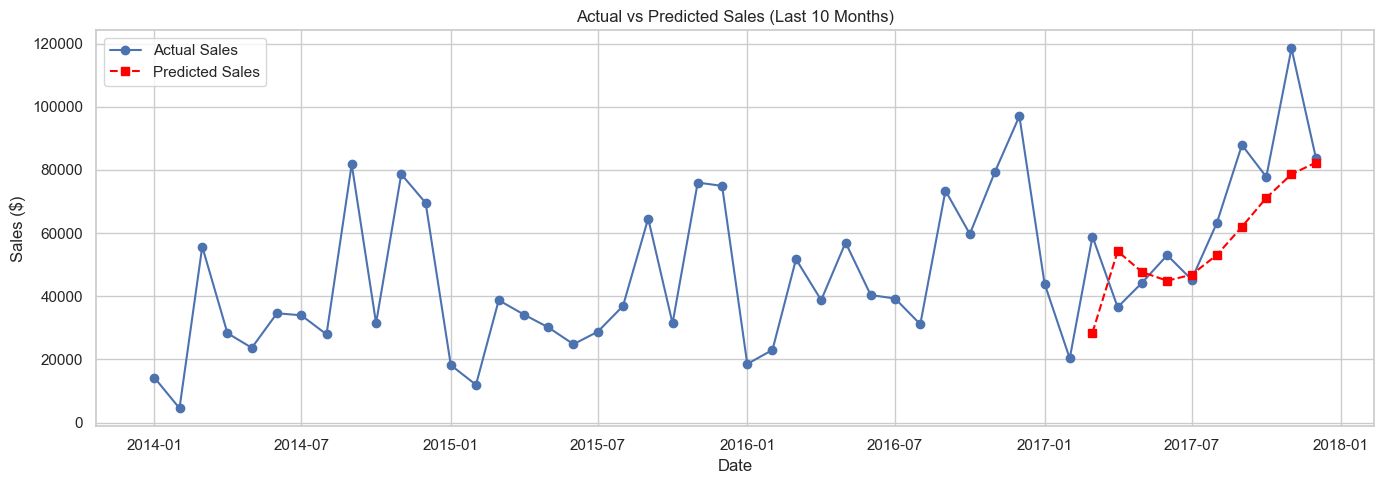

In [8]:
# Visualize predictions vs actual
plt.figure(figsize=(14, 5))

plt.plot(monthly_sales['Date'], monthly_sales['Sales'], 
         label='Actual Sales', marker='o')

plt.plot(monthly_sales['Date'].iloc[-10:], y2_pred, 
         label='Predicted Sales', marker='s', linestyle='--', color='red')

plt.title("Actual vs Predicted Sales (Last 10 Months)")
plt.ylabel("Sales ($)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## Prediction Visualization

**Observations:**
- Model correctly captures the overall upward trend
- Seasonal dip in early 2017 is partially captured
- Model cannot predict sharp sales spikes — limitation of Linear Regression
- A non-linear model like Random Forest would better capture volatility

**Conclusion:** This model is suitable for general trend forecasting 
and budget planning, but should not be used for exact monthly predictions.

In [9]:
# Forecast next 6 months (Jan 2018 - Jun 2018)
future_months = pd.DataFrame({
    'Time_Index': range(49, 55),
    'Month': [1, 2, 3, 4, 5, 6]
})

future_months['Month_Sin'] = np.sin(2 * np.pi * future_months['Month'] / 12)
future_months['Month_Cos'] = np.cos(2 * np.pi * future_months['Month'] / 12)
future_months['Q4'] = 0
future_months['Q1'] = future_months['Month'].isin([1, 2, 3]).astype(int)

future_sales = model2.predict(future_months[['Time_Index', 'Month_Sin', 'Month_Cos', 'Q4', 'Q1']])

future_months['Predicted_Sales'] = future_sales.round(2)
future_months['Date'] = pd.to_datetime({'year': 2018, 'month': future_months['Month'], 'day': 1})

print(future_months[['Date', 'Predicted_Sales']])

        Date  Predicted_Sales
0 2018-01-01         47285.94
1 2018-02-01         41983.54
2 2018-03-01         33933.94
3 2018-04-01         59678.49
4 2018-05-01         53095.83
5 2018-06-01         50334.24


In [10]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X2_train, y2_train)

rf_pred = rf_model.predict(X2_test)

rf_mae = mean_absolute_error(y2_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y2_test, rf_pred))
rf_r2 = r2_score(y2_test, rf_pred)

print("Random Forest Results:")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R² Score:", round(rf_r2, 3))

Random Forest Results:
MAE: 14116.26
RMSE: 17466.14
R² Score: 0.463


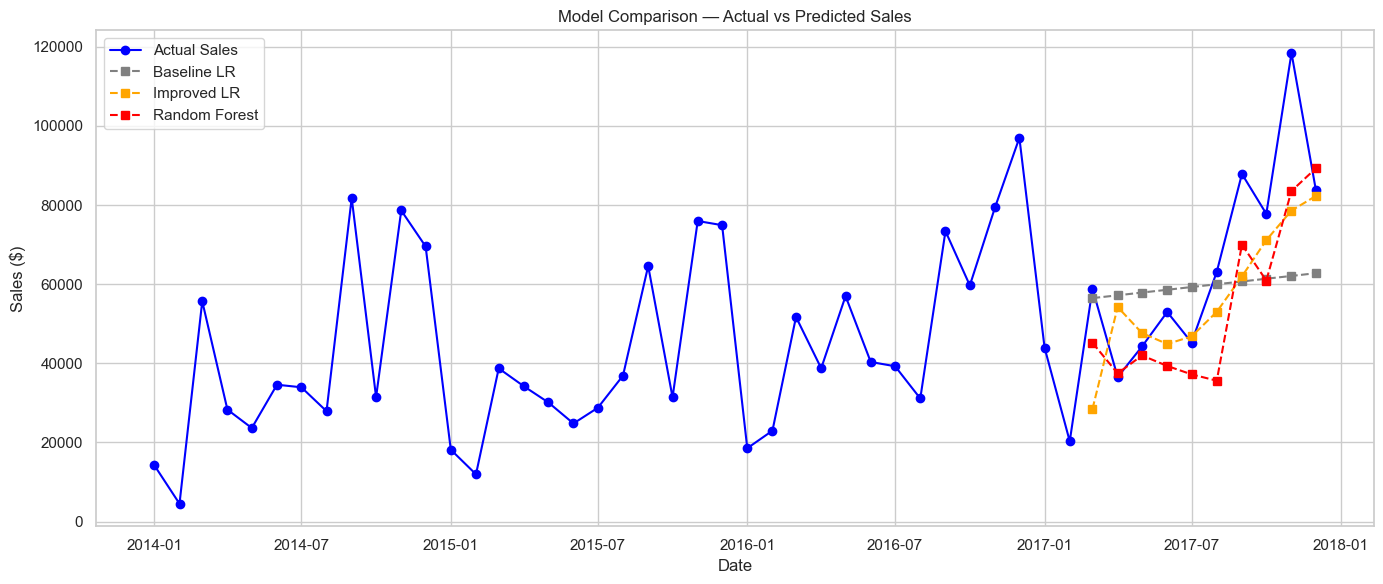

In [11]:
# Baseline predictions
y_pred_baseline = model.predict(X_test)

# Plot all three
plt.figure(figsize=(14, 6))

plt.plot(monthly_sales['Date'], monthly_sales['Sales'],
         label='Actual Sales', marker='o', color='blue')

plt.plot(monthly_sales['Date'].iloc[-10:], y_pred_baseline,
         label='Baseline LR', marker='s', linestyle='--', color='gray')

plt.plot(monthly_sales['Date'].iloc[-10:], y2_pred,
         label='Improved LR', marker='s', linestyle='--', color='orange')

plt.plot(monthly_sales['Date'].iloc[-10:], rf_pred,
         label='Random Forest', marker='s', linestyle='--', color='red')

plt.title("Model Comparison — Actual vs Predicted Sales")
plt.ylabel("Sales ($)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## Notebook 3 Summary — Sales Forecasting

### Models Built

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Baseline Linear Regression | $18,041 | $23,416 | 0.034 |
| Improved Linear Regression | $14,512 | $19,291 | 0.345 |
| Random Forest | $14,116 | $17,466 | 0.463 |

### What We Did
1. Prepared monthly sales time series from 9,994 raw orders
2. Built a baseline Linear Regression model using time index only
3. Engineered seasonal features — sin/cos encoding, Q4 and Q1 flags
4. Improved Linear Regression with seasonal features — R² jumped from 0.034 to 0.345
5. Built a Random Forest model — further improved R² to 0.463
6. Compared all three models visually and numerically
7. Generated 6 month forecast for Jan–Jun 2018

### Key Takeaways
- Seasonal feature engineering is the single biggest improvement lever
- Random Forest outperforms Linear Regression on volatile sales data
- No model captured extreme spikes — these require external data like promotions
- Q1 is consistently the weakest period, Q4 the strongest

### Limitations & Next Steps
- R² of 0.463 means 53.7% of variation is still unexplained
- Adding features like promotions, holidays, and economic indicators would improve accuracy
- XGBoost or LSTM neural networks would be the recommended next step
- Model should be retrained monthly as new sales data arrives